In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)
import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")

# Carregar o dataset limpo
df = pd.read_csv("../data/processed/stroke_limpo.csv")

# Separar features (X) do target (y)
# X = tudo que o modelo vai usar pra aprender
# y = o que queremos prever (teve AVC ou não)
X = df.drop(columns=["stroke"])
y = df["stroke"]

# Dividir em treino (80%) e teste (20%)
# random_state garante que a divisão seja sempre a mesma
# stratify=y garante que a proporção de AVC seja mantida nos dois conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("\nProporção de AVC no treino:", y_train.mean().round(3))
print("Proporção de AVC no teste:", y_test.mean().round(3))

Treino: (4087, 10)
Teste: (1022, 10)

Proporção de AVC no treino: 0.049
Proporção de AVC no teste: 0.049


In [2]:
# Separar colunas numéricas e categóricas
# O Pipeline vai tratar cada tipo de forma diferente
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# Pipeline para colunas numéricas: padronizar os valores
# StandardScaler coloca tudo na mesma escala (média 0, desvio 1)
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Pipeline para colunas categóricas: converter texto em números
# OneHotEncoder cria uma coluna binária para cada categoria
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Unir os dois pipelines em um ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

print("\nPreprocessor criado!")

Numéricas: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Preprocessor criado!


In [3]:
# Definir os 3 modelos que vamos comparar
# class_weight="balanced" faz o modelo prestar mais atenção
# nos casos raros de AVC, corrigindo o desbalanceamento
modelos = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        class_weight="balanced", random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    )
}

resultados = {}

for nome, modelo in modelos.items():
    # Montar pipeline completo: preprocessamento + modelo
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])
    
    # Validação cruzada com 5 folds
    # f1_macro trata as classes igualmente, ideal para dados desbalanceados
    cv = cross_validate(pipe, X_train, y_train, cv=5,
                        scoring=["f1_macro", "roc_auc"],
                        return_train_score=False)
    
    f1  = cv["test_f1_macro"]
    auc = cv["test_roc_auc"]
    
    resultados[nome] = {
        "F1_mean": f1.mean(),
        "F1_std": f1.std(),
        "AUC_mean": auc.mean(),
        "AUC_std": auc.std()
    }
    
    print(f"{nome}:")
    print(f"  F1-macro: {f1.mean():.4f} (+/- {f1.std():.4f})")
    print(f"  ROC-AUC:  {auc.mean():.4f} (+/- {auc.std():.4f})")
    print()

LogisticRegression:
  F1-macro: 0.5381 (+/- 0.0150)
  ROC-AUC:  0.8397 (+/- 0.0210)

RandomForest:
  F1-macro: 0.4967 (+/- 0.0119)
  ROC-AUC:  0.8065 (+/- 0.0259)

GradientBoosting:
  F1-macro: 0.5054 (+/- 0.0177)
  ROC-AUC:  0.8441 (+/- 0.0330)



In [4]:
from sklearn.model_selection import RandomizedSearchCV

# Testar diferentes configurações da Regressão Logística
# C controla a regularização: valores menores = modelo mais simples
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs", "liblinear"],
    "model__penalty": ["l2"]
}

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ))
])

search = RandomizedSearchCV(
    pipe_lr,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Melhores parâmetros:", search.best_params_)
print("Melhor F1-macro:", search.best_score_.round(4))

/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'pen

Melhores parâmetros: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 0.1}
Melhor F1-macro: 0.5387


/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

     Sem AVC       0.99      0.73      0.84       972
     Com AVC       0.13      0.80      0.23        50

    accuracy                           0.73      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.73      0.81      1022



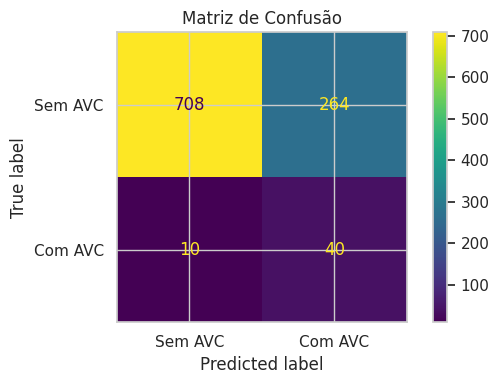

In [5]:
# Treinar o modelo final com os melhores parâmetros encontrados
modelo_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=0.1,
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

# Métricas no conjunto de teste
print(classification_report(y_test, y_pred, target_names=["Sem AVC", "Com AVC"]))

# Matriz de confusão
# Mostra quantos acertos e erros o modelo cometeu em cada classe
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Sem AVC", "Com AVC"],
    ax=ax
)
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.savefig("../screenshots/confusion_matrix.png")
plt.show()